<a href="https://colab.research.google.com/github/buk27/Smokers_LEMON_dataset/blob/main/Projekt_Smokers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The relationship between stress, anger, coping strategies and smoking**

## **Research question:** Can demographic factors predict whether someone is a smoker? To what extent do psychological factors related to stress, anger and emotional regulation relate to the likelihood of smoking?

# **Hypotheses:**
1. Certain demographic factors (i.e. **age, relationship status, level of education**)  can predict whether someone is a smoker.
2. **(TICS)** High level of stress, especially in the social dimension, is connected to being a smoker.
3. **(STAXI)** Anger experience and anger regulation styles are associated with smoking behavior.
4. **(Brief COPE)** Evasive and avoidant coping strategies influence the possibility of becoming a smoker.
5. **(CERQ)** Smoking behavior is related to less efective (maladaptive) ways of cognitively reappraising a stressful situation.

In [ ]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Functions

In [ ]:
def load_data(path):
  """
  Load CSV data and rename subject column.
  """
  df = pd.read_csv(path)
  return df.rename(columns={"Unnamed: 0": "Subject"})

In [ ]:
def prepare_smoker(df, is_smoker):
  """
  Prepare binary smoker variable (0 = non-smoker, 1 = smoker + occasional smoker).
  """
  df = df.copy()
  df = df.rename(columns={is_smoker: "Smoker"})
  df = df.dropna(subset=["Smoker"])
  df["Smoker"] = df["Smoker"].apply(lambda x: 0 if x == 1 else 1)
  return df

In [ ]:
def merge(df):
  """
  Merge data with smoker information by subject ID.
  """
  return df.merge(is_smoker, on='Subject') ## is_smoker created before we use merge

In [ ]:
def prepare_X_y(df, features):
  """
  Split data into features (X) and target (y).
  """
  data = df[features + ["Smoker"]].dropna()
  X = data[features]
  y = data["Smoker"]
  return X, y

In [ ]:
def show_corr(X):
  """
  Plot Pearson correlation matrix for features.
  """
  X_corr = X.corr(method="pearson")
  plt.figure(figsize=(12,10))
  sns.heatmap(X_corr, annot=True, cmap='coolwarm')
  return plt.show()

In [ ]:
# Run logistic regression, show the results
def reg(X, y):
  """
  Logistic regression with scaling and balanced classes.
  Prints train/test scores, confusion matrix, classification report, and coefficients.
  Returns LogisticRegression model
  """

  # split the data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

  # data scaled
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)

  # train logistic regression
  model = LogisticRegression(class_weight="balanced", max_iter=1000)
  model.fit(X_train_scaled, y_train)

  # predictions
  y_train_pred = model.predict(X_train_scaled)
  y_test_pred = model.predict(X_test_scaled)

  # scores
  train_score = model.score(X_train_scaled, y_train)
  test_score = model.score(X_test_scaled, y_test)
  accuracy = test_score

  # confusion matrix and classification report
  cm = confusion_matrix(y_test, y_test_pred)
  cr = classification_report(y_test, y_test_pred)

  # coefficients
  coef = pd.DataFrame({
      "Variable": X.columns,
      "Coefficient": model.coef_[0]
  }).sort_values(by="Coefficient", ascending=False)

  # print results
  print("Training score:", train_score)
  print("Test score:", test_score)
  print("\nConfusion matrix:\n", cm)
  print("\nClassification report:\n", cr)
  print("\nFeature coefficients:\n", coef)
  return model

**Why logistic regression?**

To test each of our hypotheses, we chose logistic regression as the main analytical method because the dependent variable (whether someone is a smoker or not) is binary. Due to the relatively small number of smokers and occasional smokers, we decided to group both categories togehter. Logistic regression computes a linear combination of predictor variables that forms a boundary separating two outcome categories. This linear boundary is then used to classify individuals into smoker or non-smoker groups.

# 1. Demographic factors

We chose three demographic factors: **age, education **and** relationship status**.

**Age** is commonly included in studies on smoking behavior because smoking habits often vary across the lifespan. Younger individuals may be more likely to experiment with smoking, while older individuals may have had more time to quit or develop long-term smoking habits. It is also related to generational differences in social norms and health awareness.

**Education** level is often associated with the level of health literacy, increased awareness of the risks of smoking, and better access to health-related information. Lower educational attainment has been associated with higher smoking prevalence in many populations. The database, however, only informs us about participants' secondary education, which indicates different career trajectories rather than a ranked measure of education level.

**Relationship status** may be relevant to smoking behavior because close social relationships can influence health-related behaviors. Being in a relationship is often associated with increased social support, shared routines, and greater concern for health, which may reduce the likelihood of smoking.

In [ ]:
demo_df = load_data("/content/DEMOGRAPHIC_FACTORS.csv")

demo_df = prepare_smoker(demo_df,is_smoker="Smoking_num_(Non-smoker=1, Occasional Smoker=2, Smoker=3)")

In [ ]:
# Unique values present in the Education column (here: types of education)
## We want to see what categories of education we have in the data
demo_df["Education"].unique()

array(['Gymnasium', 'Realschule', 'Gymansium', 'Hauptschule',
       'Somato meeting: Tuesday, 19.12.17 at 13:00 in A110',
       'none (Hauptschule not finished)'], dtype=object)

In [ ]:
# One row has a wrong category (change it to "Gymnasium")
demo_df.loc[demo_df["Education"].str.contains("Somato", na=False),"Education"] = "Gymnasium"

In [ ]:
# Categories of Education column
## Necessary for mapping later
edu_order = [
    "Gymansium",
    "Gymnasium",
    "Realschule",
    "Hauptschule",
    "none (Hauptschule not finished)"]

In [ ]:
# Remove all rows with NaN in Education
demo_df = demo_df.dropna(subset=["Education"])

In [ ]:
def edu_cat(edu):
  """
  Map an education value to a numeric category.
  """
  i = edu_order.index(edu)
  if i < 2:
      return 0   # Gymnasium + Gymansium (typo correction)
  elif i < 3:
      return 1   # Realschule
  elif i < 4:
      return 2   # Hauptschule
  else:
      return 3   # none (Hauptschule not finished)

In [ ]:
demo_df["Education_cat"] = demo_df["Education"].apply(edu_cat)

In [ ]:
# See how many times each unique value appears in the Education column
demo_df["Education"].value_counts()

,count
Education,
Gymnasium,173
Realschule,42
Hauptschule,7
Gymansium,4
none (Hauptschule not finished),1


In [ ]:
# See how many times each unique value appears in the Education_cat column
## We use it to see if nothing got lost when we used our edu_cat function
demo_df["Education_cat"].value_counts(dropna=False)

,count
Education_cat,
0,177
1,42
2,7
3,1


In [ ]:
# Show all rows (colab wouldn't allow it before)
## Better view on the new column
pd.set_option('display.max_rows', None)

In [ ]:
# See the new column
demo_df["Education_cat"]

,Education_cat
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
# Unique values in Age column (ascending)
age_order = sorted(demo_df["Age"].unique())

In [ ]:
# Remove all rows with NaN in Education_cat
demo_df = demo_df.dropna(subset=["Age"])

In [ ]:
def age_cat(age):
  """
  Map an age group to a numeric category.
  """
  i = age_order.index(age)
  if i < 2:
    return 0 ## age 20-25, 25-30
  elif i < 4:
    return 1 ## age 30-35, 35-40
  elif i < 6:
    return 2 ## age 55-60, 60-65
  else:
    return 3 ## age 65-70+

In [ ]:
demo_df["Age_cat"] = demo_df["Age"].apply(age_cat)

In [ ]:
demo_df["Age"].value_counts()

,count
Age,
20-25,78
25-30,61
65-70,25
70-75,22
60-65,19
30-35,13
75-80,4
55-60,4
35-40,1


In [ ]:
demo_df["Age_cat"].value_counts(dropna=False)

,count
Age_cat,
0,139
3,51
2,23
1,14


In [ ]:
demo_df["Age_cat"]

,Age_cat
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,2
8,0
9,0


In [ ]:
demo_df = demo_df.dropna(subset=["Relationship_Status"])

In [ ]:
demo_df["Relationship_Status"].value_counts()

,count
Relationship_Status,
Yes,147
No,67
yes,3
no,2


In [ ]:
# Correct the typos, yes = Yes, no = No
demo_df["Relationship_Status"] = demo_df["Relationship_Status"].replace("yes", "Yes")
demo_df["Relationship_Status"] = demo_df["Relationship_Status"].replace("no", "No")

In [ ]:
# Order of the list
rel_order = ["No", "Yes"]

In [ ]:
def rel_cat(rel):
  """
  Convert relationship status into a binary category: 0 for No, 1 for Yes.
  """
  i = rel_order.index(rel)
  if i < 1:
      return 0   # No
  else:
      return 1   # Yes

In [ ]:
demo_df["Relationship_cat"] = demo_df["Relationship_Status"].apply(rel_cat)

In [ ]:
demo_df["Relationship_cat"].value_counts()

,count
Relationship_cat,
1,150
0,69


In [ ]:
# Choose the features
features_demo = [
    "Age_cat",
    "Education_cat",
    "Relationship_cat"
]

In [ ]:
# Keep only the Subject, Smoker, and demographic feature columns in demo_df (only the columns we use)
demo_df = demo_df[["Subject", "Smoker"] + features_demo]

In [ ]:
# Create a list of column names from demo_df excluding Subject and Smoker.
features_demo = [c for c in demo_df.columns if c not in ["Subject", "Smoker"]]

In [ ]:
X_demo, y_demo = prepare_X_y(demo_df, features_demo)

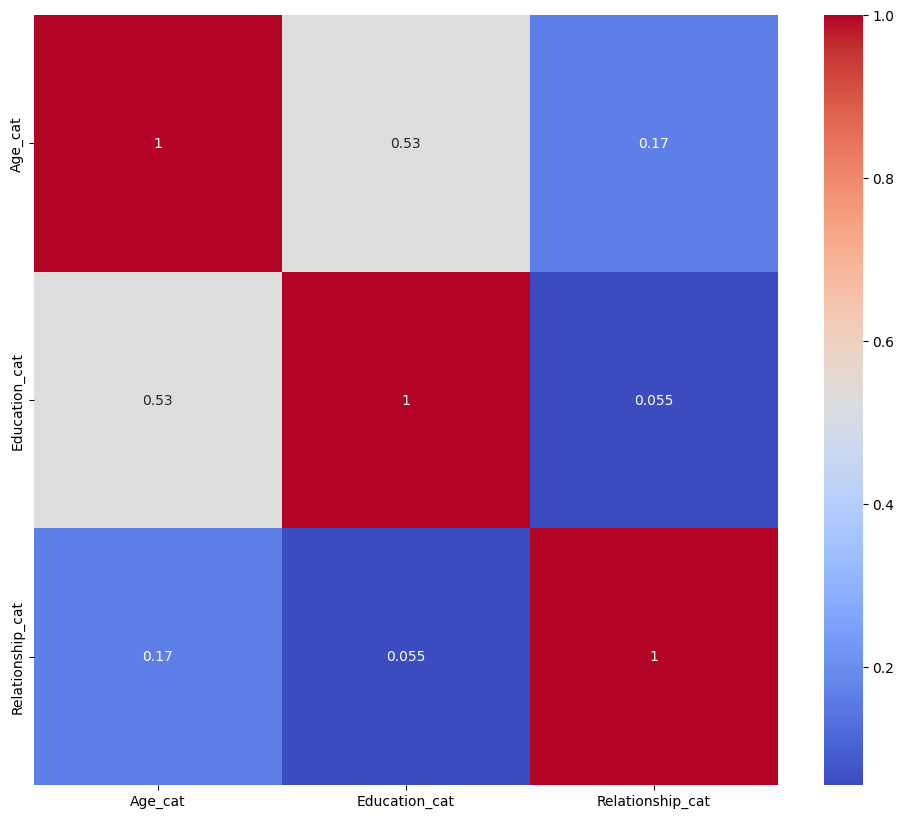

In [ ]:
show_corr(X_demo)

**Results:**

The correlation analysis indicated generally low associations (<0.6) between the variables, suggesting that each factor contributes distinct information to the model.

In [ ]:
regression_demo = reg(X_demo, y_demo)

Training score: 0.7189542483660131
Test score: 0.7424242424242424

Confusion matrix:
 [[43 12]
 [ 5  6]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.78      0.83        55
           1       0.33      0.55      0.41        11

    accuracy                           0.74        66
   macro avg       0.61      0.66      0.62        66
weighted avg       0.80      0.74      0.76        66


Feature coefficients:
            Variable  Coefficient
1     Education_cat    -0.015076
0           Age_cat    -0.399413
2  Relationship_cat    -0.425284


**Results:**

The model showed modest but stable performance across training and test sets, although overall predictive accuracy was modest. Age and relationship status provided meaningful predictive information while the coefficient for education was close to zero, suggesting that education level does not meaningfully contribute to prediction.

During the presentation we will also mention issues with the former model created for the demographic analysis.

# 2. TICS (social factors)

The **TICS (Trier Inventory for Chronic Stress)** is designed to assess chronic stress experiences across different domains of life. It focuses on long-term, recurring stressors, rather than short-term or acute stress, and includes multiple subscales. In our analysis, we focus on the subscales reflecting the social dimension of stress (**social overload, lack of social recognition and social isolation**), as these variables showed the strongest associations and best model performance in preliminary data analyses.

In [ ]:
tics_df = load_data("/content/TICS.csv")

In [ ]:
# Create is_smoker extracting the Subject and Smoker columns from demo_df
is_smoker = demo_df[["Subject", "Smoker"]]

In [ ]:
# Merge tics_df using a merge function to add smoker info
tics_df = merge(tics_df)
tics_df.head()

,Subject,TICS_WorkOverload,TICS_SocialOverload,TICS_PressuereToPerform,TICS_WorkDiscontent,TICS_WorkDemands,TICS_LackSocialRecognition,TICS_SocialTension,TICS_SocialIsolation,TICS_ChronicWorrying,TICS_ScreeningScale,Smoker
0,sub-032311,11.0,4.0,14.0,20.0,13.0,6.0,8.0,12.0,13.0,26.0,0
1,sub-032309,2.0,4.0,14.0,17.0,10.0,6.0,3.0,9.0,9.0,17.0,1
2,sub-032382,11.0,5.0,14.0,11.0,15.0,11.0,7.0,4.0,12.0,31.0,1
3,sub-032302,4.0,8.0,13.0,16.0,1.0,3.0,9.0,12.0,12.0,17.0,0
4,sub-032315,7.0,4.0,17.0,20.0,12.0,5.0,4.0,20.0,6.0,16.0,0


In [ ]:
features_tics = [
    "TICS_SocialOverload",
    "TICS_LackSocialRecognition",
    "TICS_SocialIsolation"]

tics_df = tics_df[["Subject", "Smoker"] + features_tics]

In [ ]:
X_tics, y_tics = prepare_X_y(tics_df, features_tics)

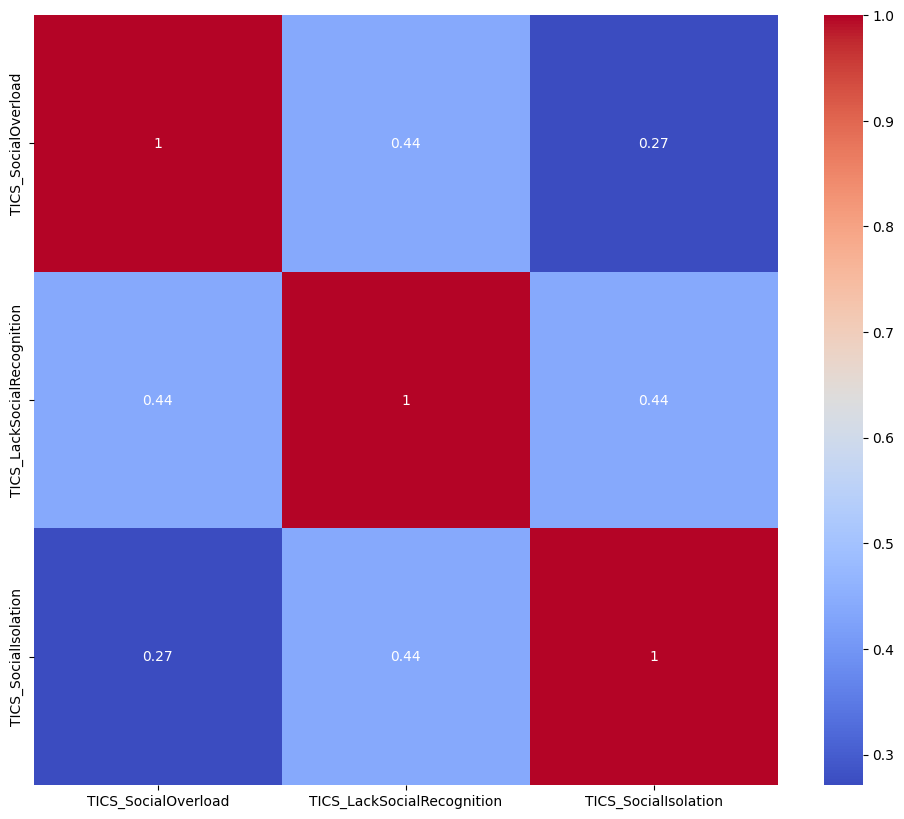

In [ ]:
show_corr(X_tics)

**Results:**

No associations above 0.6, which suggests that each factor contributes distinct information to the model.

In [ ]:
regression_tics = reg(X_tics, y_tics)

Training score: 0.5947712418300654
Test score: 0.6515151515151515

Confusion matrix:
 [[39 16]
 [ 7  4]]

Classification report:
               precision    recall  f1-score   support

           0       0.85      0.71      0.77        55
           1       0.20      0.36      0.26        11

    accuracy                           0.65        66
   macro avg       0.52      0.54      0.52        66
weighted avg       0.74      0.65      0.69        66


Feature coefficients:
                      Variable  Coefficient
1  TICS_LackSocialRecognition     0.276203
2        TICS_SocialIsolation     0.243486
0         TICS_SocialOverload    -0.120000


**Results:**

The model including social stress-related TICS subscales showed modest but stable performance, indicating that the model learned non-random structure from the data. Among the included predictors, lack of social recognition and social isolation contributed more strongly than social overload. Even though overall predictive power remained limited, we can assume that lack of social recognition and social isolation, both reflecting a sense of reduced social support and connection, have a more meaningful impact on the matter of smoking rather than social overload, which reflects an excess of social demands.

# 3. STAXI

The **STAXI (State–Trait Anger Expression Inventory)** is a psychological questionnaire designed to assess how anger is experienced, expressed, and regulated. It distinguishes between the current experience of anger (state), and habitual ways of expressing or controlling anger. Rather than measuring general emotional distress, STAXI focuses specifically on anger-related processes, which are relevant for understanding emotion regulation and health-related behaviors.

We included the following subscales: **State Anger**, **Anger In** (AI), **Anger Out** (AO), **Anger Control** (AC).

Other STAXI factors were excluded because of high correlations between some subscales, which could lead to redundancy. Our aim was to focus on distinct dimensions of anger experience, regulation, intensity, expression, and control.

In [ ]:
staxi_df = load_data("/content/STAXI.csv")

In [ ]:
staxi_df = merge(staxi_df)
staxi_df.head()

,Subject,STAXI_State_Anger,STAXI_Trait_Anger,STAXI_TAT,STAXI_TAR,STAXI_AI,STAXI_AO,STAXI_AC,Smoker
0,sub-032311,13,19,7,12,22,9,24,0
1,sub-032309,10,17,8,9,12,11,21,1
2,sub-032382,31,22,9,13,24,11,28,1
3,sub-032302,13,12,5,7,15,11,24,0
4,sub-032315,11,15,7,8,10,9,24,0


In [ ]:
features_staxi = [
    "STAXI_State_Anger",
    "STAXI_AI",
    "STAXI_AO",
    "STAXI_AC"]

staxi_df = staxi_df[["Subject", "Smoker"] + features_staxi]

In [ ]:
X_staxi, y_staxi = prepare_X_y(staxi_df, features_staxi)

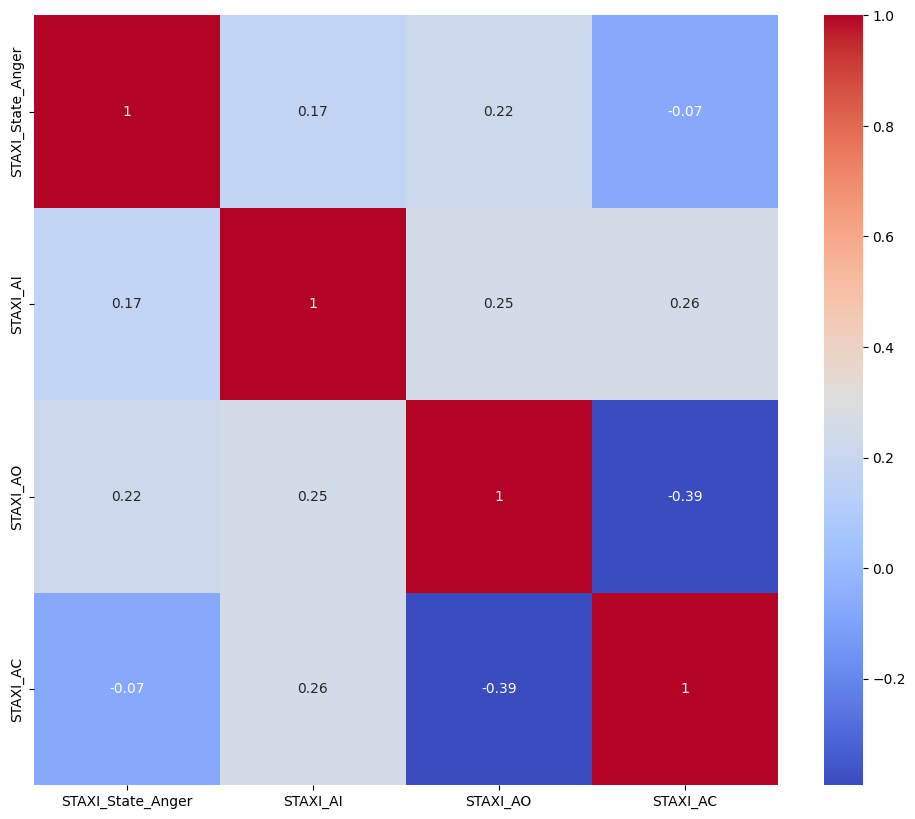

In [ ]:
show_corr(X_staxi)

**Results:**

Highly correlated predictors were excluded, resulting in no evidence of problematic multicollinearity in the final analyses.

In [ ]:
regression_staxi = reg(X_staxi, y_staxi)

Training score: 0.6666666666666666
Test score: 0.5151515151515151

Confusion matrix:
 [[27 28]
 [ 4  7]]

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.49      0.63        55
           1       0.20      0.64      0.30        11

    accuracy                           0.52        66
   macro avg       0.54      0.56      0.47        66
weighted avg       0.76      0.52      0.57        66


Feature coefficients:
             Variable  Coefficient
0  STAXI_State_Anger     0.409746
2           STAXI_AO     0.363828
3           STAXI_AC     0.009031
1           STAXI_AI    -0.621462


**Results:**

The model including STAXI subscales showed weak and unstable predictive performance, with a notable decrease from training to test accuracy. State anger and anger expression (Anger Out) showed larger coefficients, whereas anger control contributed little to the model. Overall, anger-related variables alone provided limited predictive value.

# 4. Brief COPE

The **Brief COPE** is a widely used self-report questionnaire designed to measure the cognitive and behavioral ways people respond to stressful situations. It includes both adaptive and maladaptive coping strategies.

In [ ]:
cope_df = load_data("/content/COPE.csv")

In [ ]:
cope_df = merge(cope_df)
cope_df.head()

,Subject,COPE_SelfDistraction,COPE_UseOfEmotionalSupport,COPE_BehavioralDisengagement,COPE_positiveReframing,COPE_Humor,COPE_Alkohol‎_Drogen,COPE_UseOfInstrumentalSupport,COPE_Venting,COPE_Planning,COPE_Acceptance,COPE_SelfBlame,COPE_Religion,COPE_Denial,COPE_activeCoping,Smoker
0,sub-032311,6,6,2,6,5,2,7,5,5,6,5,4,4,4,0
1,sub-032309,5,4,3,3,3,4,4,2,4,5,5,2,2,4,1
2,sub-032382,6,5,3,4,4,2,7,4,7,7,6,2,4,7,1
3,sub-032302,8,6,4,4,3,5,6,3,7,6,4,4,5,6,0
4,sub-032315,3,5,4,5,6,2,5,5,5,6,4,2,2,7,0


## 4.1. COPE evasive

**Evasive coping** refers primarily to distancing oneself from a stressor. Individuals using evasive coping tend to mentally avoid confronting the problem, for example by denying its importance, distracting themselves, or suppressing stress-related thoughts. This type of coping reduces immediate emotional discomfort but does not involve actively changing the stressful situation.

In the COPE evaluation, evasive coping is measured through **denial, self blame and venting**.

In [ ]:
features_cope_ev = [
    "COPE_Denial",
    "COPE_SelfBlame",
    "COPE_Venting"]

cope_ev_df = cope_df[["Subject", "Smoker"] + features_cope_ev]

In [ ]:
X_cope_ev, y_cope_ev = prepare_X_y(cope_ev_df, features_cope_ev)

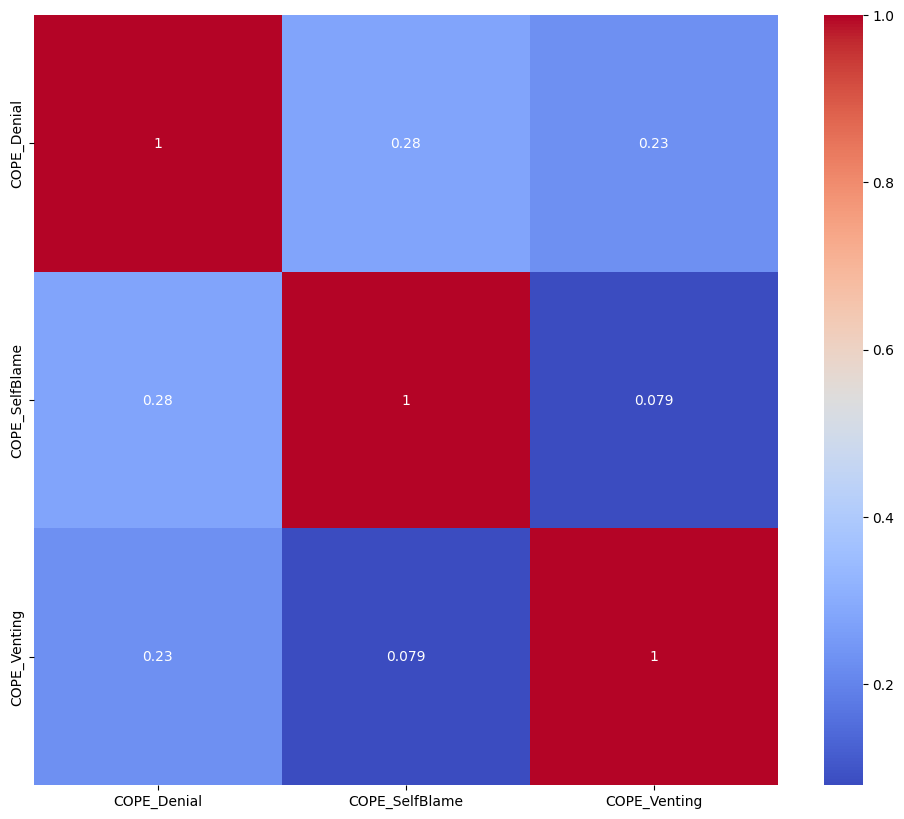

In [ ]:
show_corr(X_cope_ev)

**Results:**

No associations above 0.6, which suggests that each factor contributes distinct information to the model.

In [ ]:
regression_cope_ev = reg(X_cope_ev, y_cope_ev)

Training score: 0.6513157894736842
Test score: 0.5303030303030303

Confusion matrix:
 [[27 28]
 [ 3  8]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.49      0.64        55
           1       0.22      0.73      0.34        11

    accuracy                           0.53        66
   macro avg       0.56      0.61      0.49        66
weighted avg       0.79      0.53      0.59        66


Feature coefficients:
          Variable  Coefficient
2    COPE_Venting     0.590330
1  COPE_SelfBlame     0.422524
0     COPE_Denial    -0.328858


**Results:**

The model including evasive coping strategies showed limited predictive performance, with a notable decrease from training to test accuracy, indicating weak generalization. While venting and self-blame contributed positively to the model, denial showed a smaller and negative contribution. Overall, evasive coping strategies alone provided limited and unstable predictive information.

## 4.2. COPE avoidant

**Avoidant coping** involves behavioral withdrawal or disengagement from stressors. Rather than only distancing themselves mentally, individuals using avoidant coping may physically or behaviorally avoid stressful situations, responsibilities, or emotional engagement. This can include giving up on dealing with a problem, withdrawing from social interactions, or using behaviors to escape stress.

COPE assesses avoidant strategies through the **use of alcohol or drugs, behavioral disengagement and denial**.

In [ ]:
features_cope_av = [
    "COPE_Alkohol‎_Drogen", # the name looks like that in the dataset but shows up normally in our analysis
    "COPE_BehavioralDisengagement",
    "COPE_Denial"]

cope_av_df = cope_df[["Subject", "Smoker"] + features_cope_av]

In [ ]:
X_cope_av, y_cope_av = prepare_X_y(cope_av_df, features_cope_av)

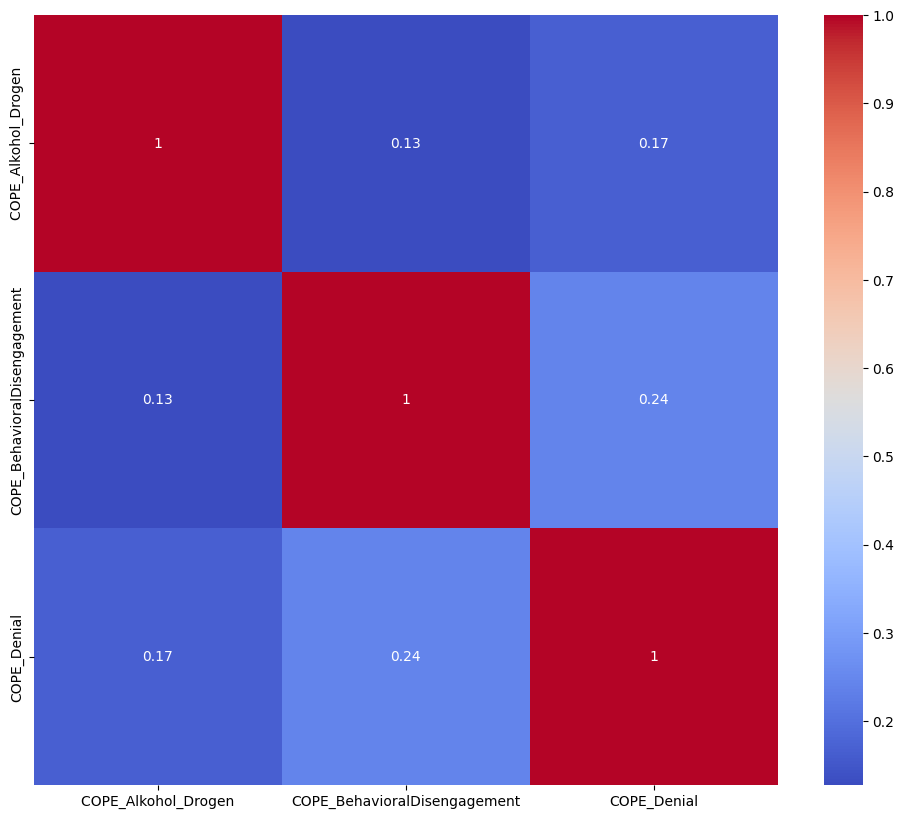

In [ ]:
show_corr(X_cope_av)

**Results:**

No associations above 0.6, which suggests that each factor contributes distinct information to the model.

In [ ]:
regression_cope_av = reg(X_cope_av, y_cope_av)

Training score: 0.7368421052631579
Test score: 0.6666666666666666

Confusion matrix:
 [[38 17]
 [ 5  6]]

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.69      0.78        55
           1       0.26      0.55      0.35        11

    accuracy                           0.67        66
   macro avg       0.57      0.62      0.56        66
weighted avg       0.78      0.67      0.71        66


Feature coefficients:
                        Variable  Coefficient
0          COPE_Alkohol‎_Drogen     0.660806
2                   COPE_Denial    -0.187058
1  COPE_BehavioralDisengagement    -0.212520


**Results:**

The logistic regression model including avoidant coping strategies showed modest but stable predictive performance, indicating that the model learned non-random structure from the data. Compared to the evasive coping model, avoidant coping variables provided a stronger predictive signal. Among the included predictors, alcohol and drug use showed the largest contribution to the model, whereas denial and behavioral disengagement contributed less. The positive contribution of substance-related coping might suggest that substance use and smoking may co-occur, indicating that these behaviors can go hand in hand as part of broader avoidant coping patterns.

# 5. CERQ (maladaptive strategies)

The **CERQ (Cognitive Emotion Regulation Questionnaire)** is a self-report questionnaire designed to assess how individuals regulate their emotions after experiencing negative or stressful events. Unlike questionnaires that focus on behavior, the CERQ specifically measures thought-based strategies people use to manage emotional responses, such as how they interpret, reframe, or dwell on stressful situations.

The CERQ distinguishes between **adaptive** and **maladaptive** cognitive strategies based on how effective they are in managing emotions over time. Adaptive strategies involve ways of thinking that help individuals process stress in a constructive manner. Maladaptive strategies involve unhelpful or dysfunctional patterns of thinking that tend to intensify or prolong negative emotional states.

In our analysis, we focus on maladaptive strategies represented by **self blame, rumination, catastrophizing and blaming others**.

In [ ]:
cerq_df = load_data("/content/CERQ.csv")

In [ ]:
cerq_df = merge(cerq_df)
cerq_df.head()

,Subject,CERQ_SelfBlame,CERQ_Acceptance,CERQ_Rumination,CERQ_positiveRefocusing,CERQ_RefocusOnPlanning,CERQ_PositiveReappraisal,CERQ_PuttingIntoPerspective,CERQ_Catastrophizing,CERQ_BlamingOthers,Smoker
0,sub-032311,7,5,6,3,4,6,5,4,4,0
1,sub-032309,5,8,5,4,3,2,2,9,5,1
2,sub-032382,6,8,4,4,11,5,6,4,3,1
3,sub-032302,6,5,4,7,10,8,8,1,3,0
4,sub-032315,5,10,5,3,4,10,6,2,0,0


In [ ]:
features_cerq = [
    "CERQ_SelfBlame",
    "CERQ_Rumination",
    "CERQ_Catastrophizing",
    "CERQ_BlamingOthers"]

cerq_df = cerq_df[["Subject", "Smoker"] + features_cerq]

In [ ]:
X_cerq, y_cerq = prepare_X_y(cerq_df, features_cerq)

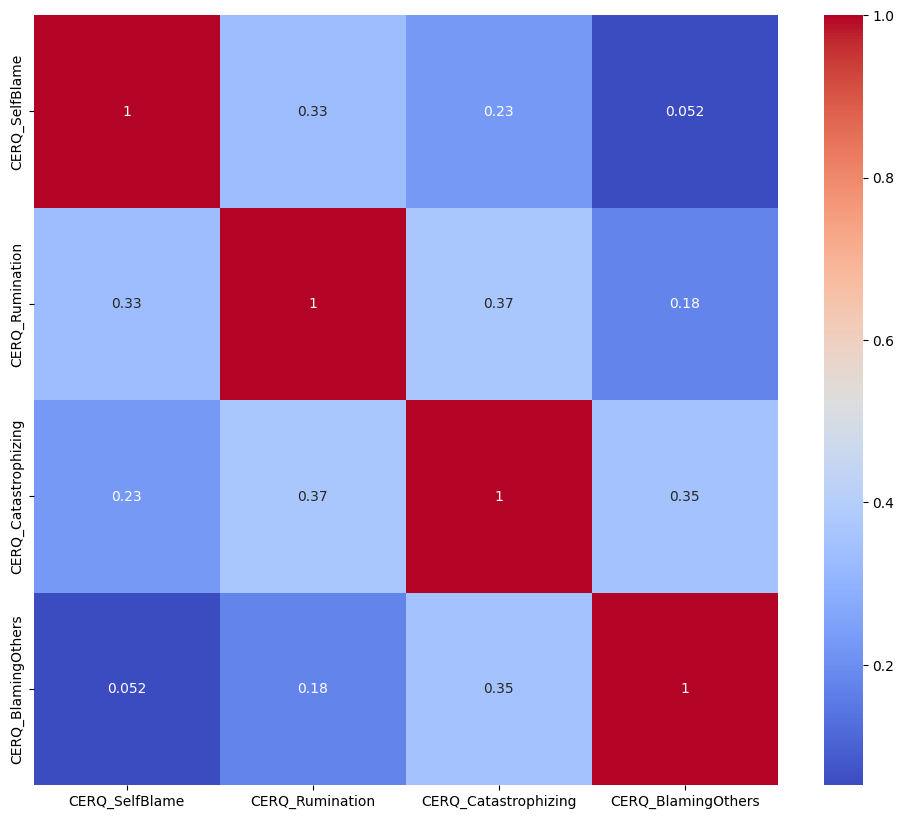

In [ ]:
show_corr(X_cerq)

**Results:**

No associations above 0.6, which suggests that each factor contributes distinct information to the model.

In [ ]:
regression_cerq = reg(X_cerq, y_cerq)

Training score: 0.6535947712418301
Test score: 0.5303030303030303

Confusion matrix:
 [[33 22]
 [ 9  2]]

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.60      0.68        55
           1       0.08      0.18      0.11        11

    accuracy                           0.53        66
   macro avg       0.43      0.39      0.40        66
weighted avg       0.67      0.53      0.59        66


Feature coefficients:
                Variable  Coefficient
2  CERQ_Catastrophizing     0.285919
0        CERQ_SelfBlame     0.184095
1       CERQ_Rumination     0.004774
3    CERQ_BlamingOthers    -0.017646


**Results:**

The model including maladaptive CERQ strategies showed weak and unstable predictive performance, with a notable decrease from training to test accuracy. Among the included predictors, catastrophizing and self-blame contributed more to the model, whereas rumination and blaming others showed minimal influence. Overall, maladaptive cognitive emotion regulation strategies alone provided limited predictive value.

# 6. Mixed Models

As the final step of our analysis, we utilized two models that included all features used up to this point. In addition to **logistic regression**, which combined both demographic variables and psychometric questionnaire measures, we also evaluated all psychometric factors using a non-linear model, the **random forest classifier**.

## 6.1. Logistic Regression

In [ ]:
staxi_df_all = load_data("/content/STAXI.csv")
tics_df_all = load_data("/content/TICS.csv")
cope_df_all = load_data("/content/COPE.csv")
cerq_df_all = load_data("/content/CERQ.csv")

In [ ]:
demo_df_all = demo_df[["Subject", "Age_cat", "Education_cat", "Relationship_cat"]]
demo_df_all.head()

,Subject,Age_cat,Education_cat,Relationship_cat
0,sub-032311,0,0,0
1,sub-032309,0,0,1
2,sub-032382,0,0,1
3,sub-032302,0,0,0
4,sub-032315,0,0,0


In [ ]:
all_df = [demo_df_all, tics_df_all, staxi_df_all, cope_df_all, cerq_df_all]

In [ ]:
# Merge all DataFrames in all_df on subject using an inner join, reset the index to make Subject a column again
## Inner join keeps only the rows where the join key exists in all DataFrames
merged_df = pd.concat([df.set_index("Subject") for df in all_df], axis=1, join="inner").reset_index()
merged_df.head()

,Subject,Age_cat,Education_cat,Relationship_cat,TICS_WorkOverload,TICS_SocialOverload,TICS_PressuereToPerform,TICS_WorkDiscontent,TICS_WorkDemands,TICS_LackSocialRecognition,...,COPE_activeCoping,CERQ_SelfBlame,CERQ_Acceptance,CERQ_Rumination,CERQ_positiveRefocusing,CERQ_RefocusOnPlanning,CERQ_PositiveReappraisal,CERQ_PuttingIntoPerspective,CERQ_Catastrophizing,CERQ_BlamingOthers
0,sub-032311,0,0,0,11.0,4.0,14.0,20.0,13.0,6.0,...,4,7,5,6,3,4,6,5,4,4
1,sub-032309,0,0,1,2.0,4.0,14.0,17.0,10.0,6.0,...,4,5,8,5,4,3,2,2,9,5
2,sub-032382,0,0,1,11.0,5.0,14.0,11.0,15.0,11.0,...,7,6,8,4,4,11,5,6,4,3
3,sub-032302,0,0,0,4.0,8.0,13.0,16.0,1.0,3.0,...,6,6,5,4,7,10,8,8,1,3
4,sub-032315,0,0,0,7.0,4.0,17.0,20.0,12.0,5.0,...,7,5,10,5,3,4,10,6,2,0


In [ ]:
merged_df = merge(merged_df)

In [ ]:
features_all = [
    "Relationship_cat",
    "Age_cat",
    "Education_cat",
    "TICS_SocialOverload",
    "TICS_LackSocialRecognition",
    "TICS_SocialIsolation",
    "STAXI_State_Anger",
    "STAXI_AI",
    "STAXI_AO",
    "STAXI_AC",
    "COPE_Denial",
    "COPE_SelfBlame",
    "COPE_Venting",
    "COPE_Alkohol‎_Drogen",
    "COPE_BehavioralDisengagement",
    "CERQ_SelfBlame",
    "CERQ_Rumination",
    "CERQ_Catastrophizing",
    "CERQ_BlamingOthers"
    ]

In [ ]:
merged_df = merged_df[["Subject", "Smoker"] + features_all]

In [ ]:
X_all, y_all = prepare_X_y(merged_df, features_all)

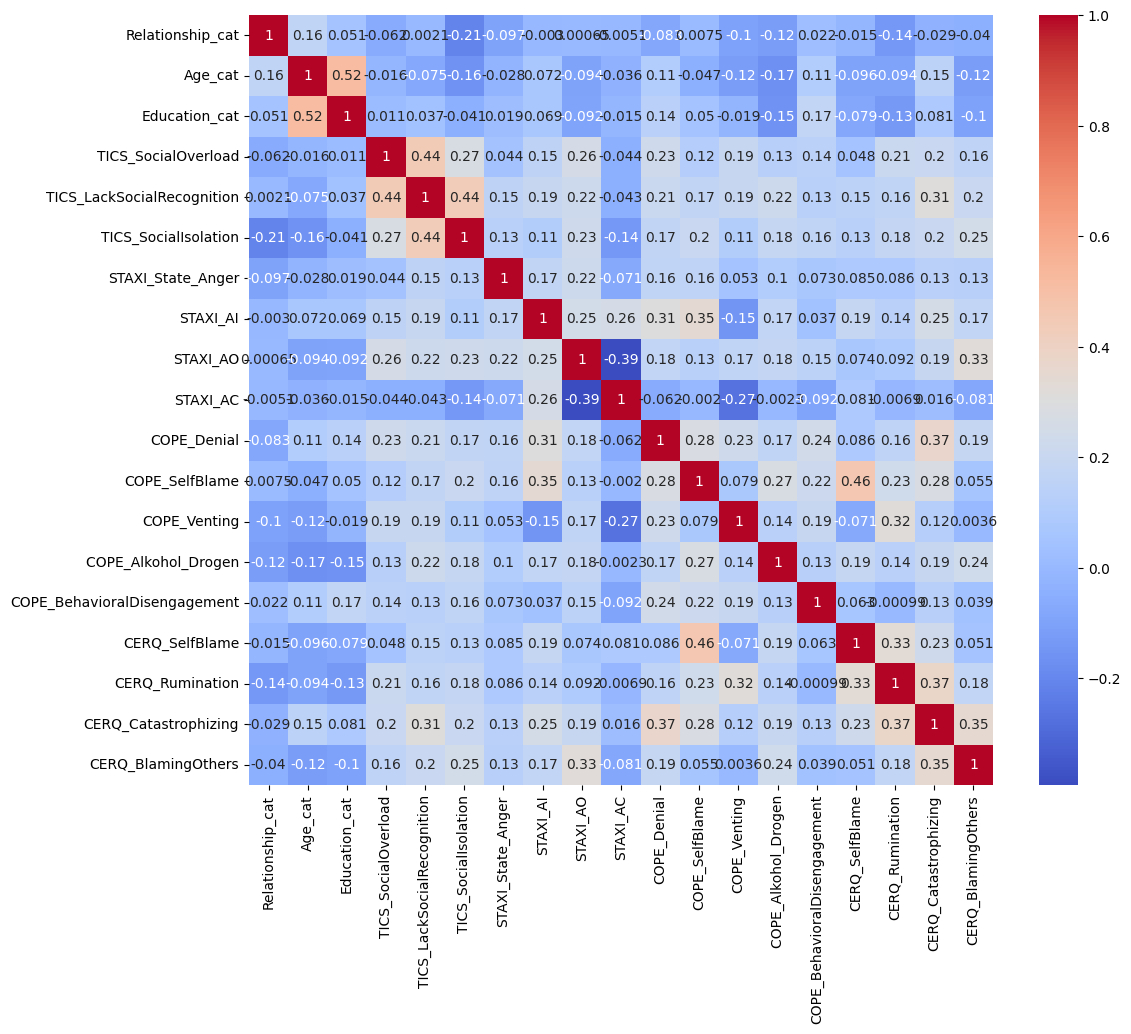

In [ ]:
show_corr(X_all)

**Results:**

Correlation analysis across all demographic and psychometric variables revealed generally low to moderate associations, with no evidence of problematic multicollinearity. Moderate correlations were observed within subscales of the same questionnaire (or the same subscale measured in different questionnaires, such as self blame in COPE and CERQ), while correlations across different questionnaires were weak. This suggests that the predictors capture overlapping yet distinct constructs and can be jointly modeled.

In [ ]:
regression_all = reg(X_all, y_all)

Training score: 0.7763157894736842
Test score: 0.6515151515151515

Confusion matrix:
 [[36 19]
 [ 4  7]]

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.65      0.76        55
           1       0.27      0.64      0.38        11

    accuracy                           0.65        66
   macro avg       0.58      0.65      0.57        66
weighted avg       0.79      0.65      0.69        66


Feature coefficients:
                         Variable  Coefficient
12                  COPE_Venting     0.514491
13          COPE_Alkohol‎_Drogen     0.489739
6              STAXI_State_Anger     0.406823
4     TICS_LackSocialRecognition     0.399262
17          CERQ_Catastrophizing     0.395349
11                COPE_SelfBlame     0.338295
8                       STAXI_AO     0.294877
5           TICS_SocialIsolation     0.195461
2                  Education_cat     0.108322
15                CERQ_SelfBlame     0.084797
9            

**Results:**

The logistic regression model including all demographic and psychometric variables showed moderate predictive performance, with evidence of non-random learning but limited generalization. Psychological variables related to coping, stress, and anger contributed more strongly to the model than demographic factors. The inclusion of all features did not lead to a substantial improvement in overall predictive accuracy.

## 6.2. Random Forest Classifier

**Random forest classifier** was applied to assess whether more complex, non-linear relationships between predictors and smoking status could improve predictive performance. Unlike logistic regression, random forests do not assume linear or additive effects and can capture interactions and threshold effects automatically. This makes random forests well suited for psychological data, where relationships between variables are often complex and non-linear. The random forest model was therefore used as a comparison model rather than a replacement for the logistic regression approach.

In [ ]:
# Re-load data and create a comprehensive merged_df
demo_df_full = load_data("/content/DEMOGRAPHIC_FACTORS.csv")
demo_df_full = prepare_smoker(demo_df_full, is_smoker="Smoking_num_(Non-smoker=1, Occasional Smoker=2, Smoker=3)")
is_smoker_rf = demo_df_full[["Subject", "Smoker"]]

In [ ]:
tics_df_full = load_data("/content/TICS.csv")
staxi_df_full = load_data("/content/STAXI.csv")
cope_df_full = load_data("/content/COPE.csv")
cerq_df_full = load_data("/content/CERQ.csv")

In [ ]:
# Merge all DataFrames into a single, comprehensive DataFrame
# Start with smoker status and subject IDs
rf_merged_df = is_smoker_rf.copy()

In [ ]:
# Merge other DataFrames
rf_merged_df = pd.merge(rf_merged_df, tics_df_full, on='Subject', how='inner')
rf_merged_df = pd.merge(rf_merged_df, staxi_df_full, on='Subject', how='inner')
rf_merged_df = pd.merge(rf_merged_df, cope_df_full, on='Subject', how='inner')
rf_merged_df = pd.merge(rf_merged_df, cerq_df_full, on='Subject', how='inner')

In [ ]:
# Select Features (X)
# We use a mix of Chronic Stress, Anger traits, and Emotion Regulation
features = [
    "TICS_SocialOverload",
    "TICS_LackSocialRecognition",
    "TICS_SocialIsolation",
    "STAXI_State_Anger",
    "STAXI_AI",
    "STAXI_AO",
    "STAXI_AC",
    "COPE_Denial",
    "COPE_SelfBlame",
    "COPE_Venting",
    "COPE_Alkohol‎_Drogen",
    "COPE_BehavioralDisengagement",
    "CERQ_SelfBlame",
    "CERQ_Rumination",
    "CERQ_Catastrophizing",
    "CERQ_BlamingOthers"
]

In [ ]:
# Use the newly created rf_merged_df
X, y = prepare_X_y(rf_merged_df, features)

In [ ]:
# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
# Evaluate the results
predictions = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94        39
           1       0.50      0.20      0.29         5

    accuracy                           0.89        44
   macro avg       0.70      0.59      0.61        44
weighted avg       0.86      0.89      0.86        44



In [ ]:
# Identify the most influential psychological factors
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nPsychological Predictors of Smoking (Ranked by Importance):")
print(importances)


Psychological Predictors of Smoking (Ranked by Importance):
STAXI_AI                        0.106437
TICS_SocialIsolation            0.088488
STAXI_AC                        0.084757
TICS_LackSocialRecognition      0.084292
COPE_Alkohol‎_Drogen            0.080669
CERQ_Rumination                 0.073033
TICS_SocialOverload             0.066336
STAXI_AO                        0.059478
CERQ_SelfBlame                  0.057612
CERQ_Catastrophizing            0.050990
COPE_Venting                    0.050314
COPE_Denial                     0.047647
COPE_SelfBlame                  0.039755
CERQ_BlamingOthers              0.039136
COPE_BehavioralDisengagement    0.037198
STAXI_State_Anger               0.033857
dtype: float64


**Results:**

The model achieved a high overall accuracy of 0.89; however, this result is mainly driven by the class imbalance in the dataset. The model performed very well in predicting the majority class, as shown by the high precision and recall values for class 0. In contrast, performance for the minority class was much weaker, with low recall and a low F1-score, indicating that many positive cases were not correctly identified. This imbalance is also reflected in the macro-averaged metrics, which show lower overall performance across classes. Overall, the results suggest that the model learned strong patterns for the majority class but had limited ability to accurately predict the minority class.

Feature importance analysis from the random forest model showed that no single psychological variable dominated prediction, with importance values distributed across multiple factors. Anger regulation variables and social stress-related measures ranked highest, followed by coping and maladaptive cognitive strategies. Overall, the results suggest that smoking-related prediction is driven by a combination of emotional regulation, social stress, and coping processes rather than any single psychological factor.